<a href="https://colab.research.google.com/github/TummalaSharmila/MachineLearning_in_BI/blob/PROJECT/ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Columns in dataset: ['Age', 'Age（0:≤65;1:>65）', 'Sex(1:Male;2:Female)', 'Race(1:White;2:Black;3:API;4:AIN)', 'Primary Site(C34.0-Main bronchus;C34.1-Upper lobe, lung;C34.2-Middle lobe, lung;C34.3-Lower lobe, lung;C34.8-Overlapping lesion of lung;C34.9-Lung,NOS)', 'Surgery(0:No;1:Yes2:others)', 'Radiation(0:NO;1:YES;2:others)', 'Chemotherapy(0:NO;1:YES)', 'Marital status(1:Married;2:Single and Unmarried;3:others)', 'Survival months', 'Mets at DX-bone(0:NO;1:YES)', 'Mets at DX-brain (0:NO;1:YES)', 'Mets at DX-liver(0:NO;1:YES)', 'Mets at DX-lung(0:NO;1:YES)', 'Laterality(1:Left;2:Right;3:Paired site;4:others)', 'T(0:1;1:2;2:3;3:4)', 'N(1:0;2:1;3:2;4:3)', 'Tumor Size', 'Tumor Size（0:≤50;1:50-100;2:>100）']


<ipython-input-1-011ee5f42477>:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[numeric_features] = scaler.fit_transform(X[numeric_features])


Random Forest - Accuracy: 0.835, ROC AUC: 0.877, Precision-Recall AUC: 0.880
AdaBoost - Accuracy: 0.813, ROC AUC: 0.861, Precision-Recall AUC: 0.865
Gradient Boosting - Accuracy: 0.844, ROC AUC: 0.887, Precision-Recall AUC: 0.890


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:11:35] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost - Accuracy: 0.825, ROC AUC: 0.868, Precision-Recall AUC: 0.875
[LightGBM] [Info] Number of positive: 1330, number of negative: 1971
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001549 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 173
[LightGBM] [Info] Number of data points in the train set: 3301, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.402908 -> initscore=-0.393362
[LightGBM] [Info] Start training from score -0.393362
LightGBM - Accuracy: 0.829, ROC AUC: 0.873, Precision-Recall AUC: 0.877
CatBoost - Accuracy: 0.840, ROC AUC: 0.886, Precision-Recall AUC: 0.888
Best performing model: Gradient Boosting


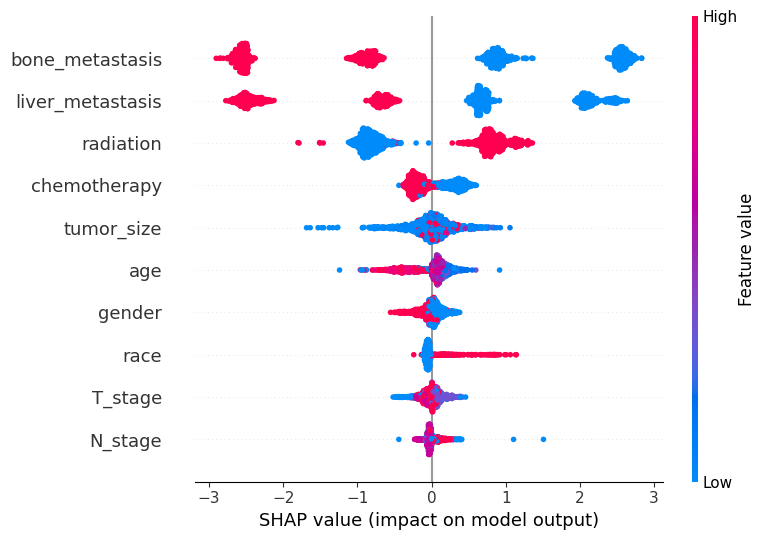

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score, precision_recall_curve, auc
import shap
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("ES-SCLC.csv")

# Print column names for debugging
print("Columns in dataset:", data.columns.tolist())

# Rename columns to simplify processing
column_mapping = {
    "Age": "age",
    "Sex(1:Male;2:Female)": "gender",
    "Race(1:White;2:Black;3:API;4:AIN)": "race",
    "Tumor Size": "tumor_size",
    "Mets at DX-bone(0:NO;1:YES)": "bone_metastasis",
    "Mets at DX-liver(0:NO;1:YES)": "liver_metastasis",
    "Radiation(0:NO;1:YES;2:others)": "radiation",
    "Chemotherapy(0:NO;1:YES)": "chemotherapy",
    "T(0:1;1:2;2:3;3:4)": "T_stage",
    "N(1:0;2:1;3:2;4:3)": "N_stage",
    "Mets at DX-brain (0:NO;1:YES)": "brain_metastasis"
}
data = data.rename(columns=column_mapping)

# Identify categorical and numerical features
categorical_features = ["gender", "race", "radiation", "chemotherapy", "N_stage", "T_stage"]
numeric_features = ["age", "tumor_size", "bone_metastasis", "liver_metastasis"]

# Verify which features exist in dataset
numeric_features = [col for col in numeric_features if col in data.columns]
categorical_features = [col for col in categorical_features if col in data.columns]

# Handle missing values
imputer_numeric = SimpleImputer(strategy='median')
data[numeric_features] = imputer_numeric.fit_transform(data[numeric_features])

# Encoding categorical variables
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

# Preprocessing: selecting relevant features
target = "brain_metastasis"
if target not in data.columns:
    raise KeyError(f"Target column '{target}' not found in dataset")

X = data[numeric_features + categorical_features]
y = data[target]

# Standardization
scaler = StandardScaler()
X[numeric_features] = scaler.fit_transform(X[numeric_features])

# Splitting data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initialize models with high-performance algorithms
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=200, random_state=42),
    "CatBoost": CatBoostClassifier(iterations=200, verbose=0, random_state=42),
}

# Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba) if y_pred_proba is not None else (None, None, None)
    pr_auc = auc(recall, precision) if precision is not None else None

    results[name] = {"Accuracy": accuracy, "ROC AUC": roc_auc, "Precision-Recall AUC": pr_auc}
    print(f"{name} - Accuracy: {accuracy:.3f}, ROC AUC: {roc_auc:.3f}, Precision-Recall AUC: {pr_auc:.3f}")

# Feature importance analysis using SHAP for the best-performing model
best_model_name = max(results, key=lambda k: results[k]["Accuracy"])
best_model = models[best_model_name]
print(f"Best performing model: {best_model_name}")

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Ensure correct indexing for SHAP values
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # Selecting class 1 for binary classification

shap.summary_plot(shap_values, X_test)
